# IMPORTO LIBRERIE E DF

In [1]:
import os

import pandas as pd
import numpy as np

import sklearn.model_selection as skl_msel
import sklearn.metrics as skl_metr

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, recall_score
from sklearn.metrics import confusion_matrix, classification_report

from xgboost import XGBClassifier

import scipy.stats.contingency as scp_cont
import scorecardpy as sc
import optuna
import shap
import random

from IPython.display import display
%matplotlib inline

In [2]:
!pip freeze



alembic==1.18.4
anyio==4.13.0
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
arrow==1.4.0
asttokens==3.0.1
async-lru==2.3.0
attrs==26.1.0
babel==2.18.0
beautifulsoup4==4.14.3
bleach==6.3.0
catboost==1.2.10
cattrs==26.1.0
certifi==2026.4.22
cffi==2.0.0
charset-normalizer==3.4.7
cloudpickle==3.1.2
colorama==0.4.6
colorlog==6.10.1
comm==0.2.3
contourpy==1.3.3
cycler==0.12.1
debugpy==1.8.20
decorator==5.2.1
defusedxml==0.7.1
executing==2.2.1
fastjsonschema==2.21.2
flatbuffers==25.9.23
fonttools==4.62.1
fqdn==1.5.1
graphviz==0.21
greenlet==3.5.0
h11==0.16.0
httpcore==1.0.9
httpx==0.28.1
idna==3.13
ipykernel==7.2.0
ipython==9.13.0
ipython_pygments_lexers==1.1.1
ipywidgets==8.1.8
isoduration==20.11.0
jedi==0.19.2
jh2==5.0.11
Jinja2==3.1.6
joblib==1.5.3
json5==0.14.0
jsonpointer==3.1.1
jsonschema==4.26.0
jsonschema-specifications==2025.9.1
jupyter==1.1.1
jupyter-console==6.6.3
jupyter-events==0.12.1
jupyter-lsp==2.3.1
jupyter_client==8.8.0
jupyter_core==5.9.1
jupyter_server==2.17.0
jupyter_s

In [4]:
pd.options.display.max_columns = 999
pd.options.display.max_rows = 999

In [5]:
data_dir = os.path.join("..", "data")

daily_df = pd.read_parquet(os.path.join(data_dir, "daily_df.parquet"))

df_merge_SF = pd.read_parquet(os.path.join(data_dir,'df_filled_SF.parquet'))
df_merge_VC = pd.read_parquet(os.path.join(data_dir,'df_filled_VC.parquet'))
df_merge_GM = pd.read_parquet(os.path.join(data_dir,'df_filled_GM.parquet'))

# MODELLO TRAFFICO (SF)

Sviluppo un modello solo per la centralina SF con le sue variabili di agenti e cerco di capire se performa meglio essendo specifico per il traffico

## CREAZIONE DF AGENTI+METEO

In [6]:
df_merge_SF.columns

Index(['giorno', 'PM10', 'PM2.5', 'media_CO', 'mediana_CO', 'massimo_CO',
       'media_NOX', 'mediana_NOX', 'massimo_NOX', 'media_NO2', 'mediana_NO2',
       'massimo_NO2', 'media_NO', 'mediana_NO', 'massimo_NO', 'media_C6H6',
       'mediana_C6H6', 'massimo_C6H6', 'flag_PM25_missing', 'flag_PM25_GM',
       'flag_PM25_interpol', 'flag_NO2_missing', 'flag_NO2_GM',
       'flag_C6H6_missing', 'mese_giorno', 'flag_C6H6_2023',
       'flag_C6H6_interpol', 'flag_NOX_missing', 'flag_NOX_interpol',
       'flag_NOX_2019', 'flag_CO_missing', 'anno', 'flag_CO_2023',
       'flag_NO2_2023', 'flag_NO_missing', 'flag_NO_2023'],
      dtype='str')

In [7]:
#creo la colonna per la target

df_merge_SF['target_pm10'] = df_merge_SF['PM10'] > 50
df_merge_SF["target_pm10"] = df_merge_SF["target_pm10"].map({True: 1, False: 0})

df_merge_SF.target_pm10.value_counts()

target_pm10
0    659
1     46
Name: count, dtype: int64

In [8]:
#droppo le colonne di flag, le colonne 'mese_giorno' e 'anno' e la 'PM10'

df_merge_SF['giorno'] = pd.to_datetime(df_merge_SF['giorno'])

to_drop = ['flag_PM25_missing', 'flag_PM25_GM',
       'flag_PM25_interpol', 'flag_NO2_missing', 'flag_NO2_GM',
       'flag_C6H6_missing', 'mese_giorno', 'flag_C6H6_2023',
       'flag_C6H6_interpol', 'flag_NOX_missing', 'flag_NOX_interpol',
       'flag_NOX_2019', 'flag_CO_missing', 'anno', 'flag_CO_2023',
       'flag_NO2_2023', 'flag_NO_missing', 'flag_NO_2023','PM10']

for d in to_drop:
       df_merge_SF = df_merge_SF.drop(d,axis=1)

df_finale_SF = df_merge_SF.merge(daily_df, left_on='giorno', right_on='date', how='left')

## SCELTA VARIABILI

Ripeto analisi fatta per il df con solo meteo per capire quali variabili tenere. Parto già con la lista_var creata in precedenza

In [9]:
list_var = ['precipitation_sum',
                    'cloud_cover_max',
                    'wind_speed_10m_min',
                    'wind_gusts_10m_max',
                    'pressure_msl_max',
                    'soil_moisture_28_to_100cm_mean',
                    'dew_point_2m_max',
                    'temperature_2m_max',
                    'shortwave_radiation_sum'
                     ]

In [10]:
list_traffic = [#'PM2.5', 
       'media_CO', 'mediana_CO', 'massimo_CO',
       'media_NOX', 'mediana_NOX', 'massimo_NOX',
       'media_NO', 'mediana_NO', 'massimo_NO', 
       'media_NO2', 'mediana_NO2', 'massimo_NO2',
       'media_C6H6', 'mediana_C6H6', 'massimo_C6H6']

In [11]:
# creo una lista di variabili da usare nel modello per il traffico

list_var_traffic = list_var + list_traffic

In [12]:
list_var_traffic

['precipitation_sum',
 'cloud_cover_max',
 'wind_speed_10m_min',
 'wind_gusts_10m_max',
 'pressure_msl_max',
 'soil_moisture_28_to_100cm_mean',
 'dew_point_2m_max',
 'temperature_2m_max',
 'shortwave_radiation_sum',
 'media_CO',
 'mediana_CO',
 'massimo_CO',
 'media_NOX',
 'mediana_NOX',
 'massimo_NOX',
 'media_NO',
 'mediana_NO',
 'massimo_NO',
 'media_NO2',
 'mediana_NO2',
 'massimo_NO2',
 'media_C6H6',
 'mediana_C6H6',
 'massimo_C6H6']

### CORRELAZIONE

In [13]:
corr_matrix = df_finale_SF[list_var_traffic].corr(numeric_only=True)

list_corr = []
cols = corr_matrix.columns.tolist()

for ii, i in enumerate(cols[:-1]):
    for jj, j in enumerate(cols[ii+1:]):
        list_corr.append([i, j, corr_matrix.loc[i, j]])

df_corr = pd.DataFrame(list_corr, columns=['varA', 'varB', 'correlation'])
df_corr = df_corr.sort_values('correlation', ascending=False, key=abs)

df_corr.loc[df_corr['correlation'] > 0.7,:]
#df_corr.loc[df_corr['correlation'] > 0.98,:]

,varA,varB,correlation
171,media_CO,mediana_CO,0.987537
261,media_NO2,mediana_NO2,0.985737
273,media_C6H6,mediana_C6H6,0.980608
210,media_NOX,mediana_NOX,0.977190
240,media_NO,mediana_NO,0.973939
233,massimo_NOX,massimo_NO,0.946789
212,media_NOX,media_NO,0.918316
241,media_NO,massimo_NO,0.909058
123,dew_point_2m_max,temperature_2m_max,0.907007
211,media_NOX,massimo_NOX,0.904536


Vedo che le variabili riguardanti gli agenti sono particolarmente correlate tra loro, non tanto con le variabili di meteo

### VSCORE

In [14]:
df_vscore = df_finale_SF.copy()

for k in list_var_traffic :   # per ciascuna delle colonne numeriche ...

    df_vscore[k] = pd.qcut(df_vscore[k], q=min(20, df_vscore[k].nunique()+1), duplicates='drop')                     # ... binning ...
    df_vscore[k] = df_vscore[k].map({k:'bin'+f'{kk}'.zfill(2) for kk,k in enumerate(sorted(df_vscore[k].unique()))}) # ... resetting labels

In [15]:
list_vscores = []

list_vars_vscore = list_var_traffic
list_vars_vscore = list(df_vscore[list_vars_vscore].nunique().sort_values(ascending=False).index)

for ii, i in enumerate(list_vars_vscore[:-1]) :
    for jj, j in enumerate(list_vars_vscore[ii+1:]) :

        df_contingency = df_vscore.groupby([i,j]).agg({'giorno':'count'})
        df_contingency = df_contingency.unstack().replace(0, np.nan)
        df_contingency = df_contingency.dropna(axis=0, how='all').dropna(axis=1, how='all')
        df_contingency = df_contingency.fillna(0).astype(int)

        r, c = df_contingency.shape
        n = df_contingency.sum().sum()

        vscore = scp_cont.association(df_contingency.values, method="tschuprow")
        vscore = max(0, vscore**2 * np.sqrt((c-1) * (r-1)) * (n-1) - (r-1) * (c-1))
        vscore = vscore / min( (r-1) * (n-c), (c-1) * (n-r) )
        vscore = np.sqrt(vscore)

        list_vscores.append([i,j,vscore])

df_vscore = pd.DataFrame(list_vscores, columns=['varA', 'varB', 'v-score'])
df_vscore = df_vscore.sort_values('v-score', ascending=False)

In [16]:
df_vscore.head(20).style.background_gradient(vmin=0, vmax=1).format(precision=2)

,varA,varB,v-score
137,media_CO,mediana_CO,0.71
180,media_C6H6,mediana_C6H6,0.58
248,media_NO2,mediana_NO2,0.56
185,mediana_NOX,media_NOX,0.50
222,media_NO,mediana_NO,0.50
136,media_CO,massimo_CO,0.43
270,massimo_CO,mediana_CO,0.40
267,mediana_C6H6,mediana_CO,0.39
182,media_C6H6,mediana_CO,0.38
262,massimo_C6H6,massimo_CO,0.38


Stessa osservazione fatta per le correlazioni, il vscore tra variabili di agenti e di meteo non è particolarmente alto

In [17]:
# ora guardo il vscore a tre
df_vscore = df_finale_SF.copy()

for k in list_var_traffic :   # per ciascuna delle colonne numeriche ...

    df_vscore[k] = pd.qcut(df_vscore[k], q=min(20, df_vscore[k].nunique()+1), duplicates='drop')                     # ... binning ...
    df_vscore[k] = df_vscore[k].map({k:'bin'+f'{kk}'.zfill(2) for kk,k in enumerate(sorted(df_vscore[k].unique()))}) # ... resetting labels

In [18]:
list_vscores = []

list_vars_vscore = list_var_traffic
list_vars_vscore = list(df_vscore[list_vars_vscore].nunique().sort_values(ascending=False).index)

for ii, i in enumerate(list_vars_vscore[:-2]) :
    for jj, j in enumerate(list_vars_vscore[ii+1:-1]) :
        for kk, k in enumerate(list_vars_vscore[ii+jj+2:]) :

            df_contingency = df_vscore.groupby([i,j,k]).agg({'giorno':'count'})
            df_contingency = df_contingency.unstack().replace(0, np.nan)
            df_contingency = df_contingency.dropna(axis=0, how='all').dropna(axis=1, how='all')
            df_contingency = df_contingency.fillna(0).astype(int)

            r, c = df_contingency.shape
            n = df_contingency.sum().sum()

            #vscore = scp_cont.association(df_contingency.values, method="cramer") # no - sovrastima le numeriche
            vscore = scp_cont.association(df_contingency.values, method="tschuprow")
            vscore = max(0, vscore**2 * np.sqrt((c-1) * (r-1)) * (n-1) - (r-1) * (c-1))
            vscore = vscore / min( (r-1) * (n-c), (c-1) * (n-r) )
            vscore = np.sqrt(vscore)

            list_vscores.append([i,j,k,vscore])

df_vscore = pd.DataFrame(list_vscores, columns=['varA0', 'varA1', 'varB', 'v-score'])
df_vscore = df_vscore.sort_values('v-score', ascending=False)

In [19]:
df_vscore.head(20).style.background_gradient(vmin=.9, vmax=1).format(precision=2)

,varA0,varA1,varB,v-score
916,dew_point_2m_max,media_CO,mediana_CO,0.75
1313,media_CO,mediana_NO,mediana_CO,0.75
1338,media_CO,massimo_CO,mediana_CO,0.74
1331,media_CO,massimo_C6H6,mediana_CO,0.74
1320,media_CO,media_NO2,mediana_CO,0.74
1250,media_CO,media_C6H6,mediana_CO,0.73
555,soil_moisture_28_to_100cm_mean,media_CO,mediana_CO,0.73
1326,media_CO,mediana_NO2,mediana_CO,0.73
1296,media_CO,media_NO,mediana_CO,0.73
1335,media_CO,mediana_C6H6,mediana_CO,0.73


### CORRELAZIONE DI PEARSON CONFRONTO PM10

In [20]:
df_corr_p = (
    df_finale_SF[list_var_traffic]
    .corrwith(df_finale_SF["target_pm10"])
    .abs()
    .sort_values(ascending=False)
    .reset_index()
)

df_corr_p.columns = ["varA", "correlation"]
df_corr_p["varB"] = "target_pm10"

df_corr_p

,varA,correlation,varB
0,mediana_C6H6,0.453515,target_pm10
1,media_C6H6,0.437552,target_pm10
2,mediana_CO,0.434283,target_pm10
3,media_CO,0.421328,target_pm10
4,media_NOX,0.414137,target_pm10
5,media_NO,0.404940,target_pm10
6,mediana_NOX,0.393802,target_pm10
7,massimo_NO,0.392124,target_pm10
8,mediana_NO,0.381399,target_pm10
9,massimo_NOX,0.376201,target_pm10


### CORRELAZIONE DI SPEARMAN CONFRONTO PM10

In [21]:
df_corr_s = (
    df_finale_SF[list_var_traffic]
    .corrwith(df_finale_SF["target_pm10"], method='spearman')
    .abs()
    .sort_values(ascending=False)
    .reset_index()
)

df_corr_s.columns = ["varA", "correlation"]
df_corr_s["varB"] = "target_pm10"

df_corr_s

,varA,correlation,varB
0,mediana_CO,0.363470,target_pm10
1,media_CO,0.356407,target_pm10
2,mediana_C6H6,0.321990,target_pm10
3,media_C6H6,0.317847,target_pm10
4,media_NOX,0.307431,target_pm10
5,massimo_CO,0.304084,target_pm10
6,mediana_NOX,0.300302,target_pm10
7,media_NO,0.286181,target_pm10
8,massimo_NO,0.273619,target_pm10
9,mediana_NO,0.271071,target_pm10


### VSCORE CONFRONTO PM10

In [22]:
df_vscore = df_finale_SF.copy()

for k in list_var_traffic:   # per ciascuna delle colonne numeriche ...

    df_vscore[k] = pd.qcut(df_vscore[k], q=min(20, df_vscore[k].nunique()+1), duplicates='drop')                                # ... binning ...
    df_vscore[k] = df_vscore[k].map({k:'bin'+f'{kk}'.zfill(2) for kk,k in enumerate(sorted(df_vscore[k].dropna().unique()))})   # ... resetting labels

In [23]:
list_vscores = []

list_vars_vscore = list_var_traffic
list_vars_vscore = list(df_vscore[list_vars_vscore].nunique().sort_values(ascending=False).index)

for ii, i in enumerate(list_vars_vscore) :

    df_contingency = df_vscore.groupby([i,'target_pm10']).agg({'giorno':'count'})
    df_contingency = df_contingency.unstack().replace(0, np.nan)
    df_contingency = df_contingency.dropna(axis=0, how='all').dropna(axis=1, how='all')
    df_contingency = df_contingency.fillna(0).astype(int)

    r, c = df_contingency.shape
    n = df_contingency.sum().sum()

    vscore = scp_cont.association(df_contingency.values, method="tschuprow")
    vscore = max(0, vscore**2 * np.sqrt((c-1) * (r-1)) * (n-1) - (r-1) * (c-1))
    vscore = vscore / min( (r-1) * (n-c), (c-1) * (n-r) )
    vscore = np.sqrt(vscore)

    list_vscores.append([i,'target_pm10',vscore])

df_couples = pd.DataFrame(list_vscores, columns=['var-x', 'var-y', 'v-score'])
df_couples = df_couples.sort_values('v-score', ascending=False)

In [24]:
df_couples.head(12).style.background_gradient(vmin=0, vmax=.3).format(precision=2)

,var-x,var-y,v-score
19,mediana_C6H6,target_pm10,0.56
6,media_CO,target_pm10,0.56
21,mediana_CO,target_pm10,0.56
9,media_C6H6,target_pm10,0.51
10,mediana_NOX,target_pm10,0.46
11,media_NOX,target_pm10,0.45
15,mediana_NO,target_pm10,0.44
13,media_NO,target_pm10,0.43
14,massimo_NO,target_pm10,0.36
12,massimo_NOX,target_pm10,0.35


In [25]:
#ora guardo per coppie di variabili e target
df_vscore = df_finale_SF.copy()

for k in list_var_traffic:               

    df_vscore[k] = pd.qcut(df_vscore[k], q=min(20, df_vscore[k].nunique()+1), duplicates='drop')                                  # ... binning ...
    df_vscore[k] = df_vscore[k].map({k:'bin'+f'{kk}'.zfill(2) for kk,k in enumerate(sorted(df_vscore[k].dropna().unique()))})     # ... resetting labels

    

In [26]:
for ii, i in enumerate(list_vars_vscore[:-1]) :
    for jj, j in enumerate(list_vars_vscore[ii+1:]) :

        df_contingency = df_vscore.groupby([i,j,'target_pm10']).agg({'giorno':'count'})
        df_contingency = df_contingency.unstack().replace(0, np.nan)
        df_contingency = df_contingency.dropna(axis=0, how='all').dropna(axis=1, how='all')
        df_contingency = df_contingency.fillna(0).astype(int)

        r, c = df_contingency.shape
        n = df_contingency.sum().sum()

        vscore = scp_cont.association(df_contingency.values, method="tschuprow")
        vscore = max(0, vscore**2 * np.sqrt((c-1) * (r-1)) * (n-1) - (r-1) * (c-1))
        vscore = vscore / min( (r-1) * (n-c), (c-1) * (n-r) )
        vscore = np.sqrt(vscore)

        list_vscores.append([i,j,'target_pm10',vscore])

df_triplets = pd.DataFrame(list_vscores, columns=['var-x0', 'var-x1', 'var-y', 'v-score'])
df_triplets = df_triplets.sort_values('v-score', ascending=False)

In [27]:
df_triplets.head(10).style.background_gradient(vmin=0, vmax=.5).format(precision=2)

,var-x0,var-x1,var-y,v-score
192,massimo_NO2,mediana_CO,target_pm10,0.73
276,media_NO2,mediana_CO,target_pm10,0.73
274,media_NO2,mediana_C6H6,target_pm10,0.71
190,massimo_NO2,mediana_C6H6,target_pm10,0.69
159,media_CO,mediana_C6H6,target_pm10,0.68
291,mediana_C6H6,mediana_CO,target_pm10,0.68
282,mediana_NO2,mediana_CO,target_pm10,0.67
105,pressure_msl_max,mediana_C6H6,target_pm10,0.66
87,soil_moisture_28_to_100cm_mean,mediana_CO,target_pm10,0.65
206,media_C6H6,mediana_CO,target_pm10,0.65


### INFORMATION VALUE CONFRONTO PM10




In [28]:
features = list_var_traffic
target = 'target_pm10'  # 1 = sopra soglia, 0 = sotto

# prendi solo le colonne che ti servono
df_sub = df_finale_SF[features + [target]]

# calcolo IV solo su queste
iv_df = sc.iv(df_sub, y=target)

In [29]:
iv_df.head(20).style.background_gradient(vmin=0, vmax=.5).format(precision=2)

,variable,info_value
17,mediana_CO,2.86
22,mediana_C6H6,2.80
8,massimo_CO,1.84
1,massimo_C6H6,1.28
4,mediana_NO,1.23
6,precipitation_sum,1.16
5,media_CO,1.09
20,massimo_NO,0.97
14,cloud_cover_max,0.72
7,media_C6H6,0.72


I valori IV più alti sono stati osservati per variabili legate a CO e C6H6. Poiché IV > 0.5 è generalmente considerato molto elevato, questi risultati sono stati interpretati con cautela. Possibili spiegazioni includono la forte co-variazione tra inquinanti urbani e lo sbilanciamento della target PM10>50. Per capire se possiamo tenere variabili con un IV così alto, guardo l'IV sul test e sul train.

In [30]:
# split direttamente sul dataframe
xtr, xte, ytr, yte = skl_msel.train_test_split(
    df_finale_SF,
    df_finale_SF['target_pm10'],
    test_size=0.30,
    random_state=33
)

# flag basati sull'index
df_finale_SF['flag train'] = df_finale_SF.index.isin(xtr.index)
df_finale_SF['flag test'] = df_finale_SF.index.isin(xte.index)

In [31]:
train_iv = xtr.copy()
train_iv[target] = ytr.values

test_iv = xte.copy()
test_iv[target] = yte.values

iv_train = sc.iv(train_iv[features + [target]], y=target)
iv_test = sc.iv(test_iv[features + [target]], y=target)

iv_compare = iv_train.merge(
    iv_test,
    on="variable",
    how="outer",
    suffixes=("_train", "_test")
)

iv_compare = iv_compare.sort_values("info_value_train", ascending=False)

iv_compare

,variable,info_value_train,info_value_test
13,mediana_CO,2.597113,1.821279
12,mediana_C6H6,2.498609,1.333269
3,massimo_CO,1.894634,0.793103
2,massimo_C6H6,1.290748,0.405023
14,mediana_NO,1.031107,0.617315
17,precipitation_sum,1.011207,1.873342
8,media_CO,0.961096,0.529993
4,massimo_NO,0.873056,0.457832
0,cloud_cover_max,0.794708,1.100624
15,mediana_NO2,0.666542,0.450285


Le variabili con IV più elevato nel training sono principalmente CO, C6H6, NO e variabili meteorologiche. Il confronto con il test set mostra che alcune di queste. Decido quindi di tenere le variabili che indicano la mediana degli agenti e di droppare quelle di media e di massimo.

In [32]:
list_var_traffic_new =['precipitation_sum',
                    'cloud_cover_max',
                    'wind_speed_10m_min',
                    'wind_gusts_10m_max',
                    'pressure_msl_max',
                    'soil_moisture_28_to_100cm_mean',
                    'dew_point_2m_max',
                    'temperature_2m_max',
                    'shortwave_radiation_sum',
                    'mediana_CO',
                    'mediana_NOX',
                    'mediana_NO',
                    'mediana_NO2',
                    'mediana_C6H6']

## MODELLO OTTIMIZZATO SUL DF COMPLETO

Applichiamo il modello ottimizzato che abbiamo trovato per il df con i dati di tutte le centraline e vediamo come si comporta sul df che contiene solo dati provenienti dalla centralina SF

In [33]:
params = {'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 700}

In [34]:
# calcolo peso per class imbalance
n_neg = (df_finale_SF['target_pm10'] == 0).sum()
n_pos = (df_finale_SF['target_pm10'] == 1).sum()
scale_pos_weight = n_neg / n_pos

cla_xgb = XGBClassifier(
    **params,
    scale_pos_weight=scale_pos_weight
)

cla_xgb.fit(
    df_finale_SF.loc[df_finale_SF['flag train'], list_var_traffic_new].values,
    df_finale_SF.loc[df_finale_SF['flag train'], 'target_pm10'].values
)

# probabilità della classe 1
df_finale_SF['proba (xgb)'] = cla_xgb.predict_proba(
    df_finale_SF.loc[:, list_var_traffic_new].values
)[:, 1]

df_finale_SF['prediction (xgb)'] = (df_finale_SF['proba (xgb)'] > 0.3).astype(int)

### PRECISION

In [35]:
pre_xgb = skl_metr.precision_score(df_finale_SF.loc[df_finale_SF['flag test'], 'target_pm10'] == 1,
                                    df_finale_SF.loc[df_finale_SF['flag test'], 'prediction (xgb)'] == 1)

print(f'Model precision (decision xgb): {pre_xgb:.2}')

Model precision (decision xgb): 0.33


### RECALL

In [36]:
rec_xgb = skl_metr.recall_score(df_finale_SF.loc[df_finale_SF['flag test'], 'target_pm10'] == 1,
                                 df_finale_SF.loc[df_finale_SF['flag test'], 'prediction (xgb)'] == 1)

print(f'Model recall (xgb): {rec_xgb:.2}')

Model recall (xgb): 0.45


### TABLE

In [37]:
df_pivot = pd.pivot_table(df_finale_SF.loc[df_finale_SF['flag test'], :],
                          index='target_pm10', columns='prediction (xgb)',
                          values='giorno', aggfunc='count', fill_value=0)
df_pivot.style.background_gradient(vmin=0, vmax=5).format(precision=0)

prediction (xgb),0,1
target_pm10,,
0,191,10
1,6,5


In [38]:
df_test = df_finale_SF.loc[df_finale_SF['flag test']]

y_true = df_test['target_pm10']

models = {
    "xgb": "prediction (xgb)"
}

results = []

for name, col in models.items():
    y_pred = df_test[col]

    results.append({
        "Model": name,
        "Accuracy": skl_metr.accuracy_score(y_true, y_pred),
        "Precision": skl_metr.precision_score(y_true, y_pred),
        "Recall": skl_metr.recall_score(y_true, y_pred),
        "F1-score": skl_metr.f1_score(y_true, y_pred),
        "MCC": skl_metr.matthews_corrcoef(y_true, y_pred)
    })

df_results = pd.DataFrame(results)

df_results = df_results.round(4)
df_results

,Model,Accuracy,Precision,Recall,F1-score,MCC
0,xgb,0.9245,0.3333,0.4545,0.3846,0.3501


## MODELLO TRAFFICO OTTIMIZZATO

Dato che il modello definitivo sopra non ha recall molto alta, provo ad ottimizzare il modello su questo df per vedere se è possibile alzare la recall senza diminuire troppo accuracy e precision

In [39]:

# train/test usando le tue flag
df_train = df_finale_SF.loc[df_finale_SF["flag train"]].copy()
df_test = df_finale_SF.loc[df_finale_SF["flag test"]].copy()

X_train = df_train[list_var_traffic]
y_train = df_train["target_pm10"]

X_test = df_test[list_var_traffic]
y_test = df_test["target_pm10"]

# peso classe positiva calcolato sul train
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight_base = n_neg / n_pos

print("n_neg:", n_neg)
print("n_pos:", n_pos)
print("scale_pos_weight_base:", scale_pos_weight_base)

n_neg: 458
n_pos: 35
scale_pos_weight_base: 13.085714285714285


In [40]:

# Seed globali
np.random.seed(48)
random.seed(48)

# Modello base
xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    seed=42,
    n_jobs=1,              # più deterministico rispetto a -1
    tree_method="hist"     # metodo stabile e veloce su CPU
)

# Spazio dei parametri
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.5, 1],
    "reg_lambda": [1, 2, 5],
    "scale_pos_weight": [
        scale_pos_weight_base,
        scale_pos_weight_base * 1.5,
        scale_pos_weight_base * 2
    ]
}

# Scorer per ottimizzare la recall
recall_scorer = make_scorer(recall_score, zero_division=0)

# Ricerca randomizzata
random_xgb_recall = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=80,
    scoring=recall_scorer,
    cv=3,
    n_jobs=1,              # più deterministico rispetto a -1
    verbose=1,
    random_state=48
)

# Fit
random_xgb_recall.fit(X_train, y_train)

# Risultati CV
print("Miglior recall CV:", random_xgb_recall.best_score_)
print("Migliori parametri:")
print(random_xgb_recall.best_params_)

# Miglior modello trovato
best_xgb_recall = random_xgb_recall.best_estimator_

# Valutazione sul test set
y_pred = best_xgb_recall.predict(X_test)

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

Fitting 3 folds for each of 80 candidates, totalling 240 fits
Miglior recall CV: 0.73989898989899
Migliori parametri:
{'subsample': 0.7, 'scale_pos_weight': np.float64(26.17142857142857), 'reg_lambda': 5, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.7}

Confusion matrix:
[[180  21]
 [  4   7]]

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.90      0.94       201
           1       0.25      0.64      0.36        11

    accuracy                           0.88       212
   macro avg       0.61      0.77      0.65       212
weighted avg       0.94      0.88      0.91       212



In [41]:
best_xgb = random_xgb_recall.best_estimator_

df_finale_SF["proba_xgb_opt"] = best_xgb.predict_proba(
    df_finale_SF[list_var_traffic]
)[:, 1]

# soglia iniziale 0.5
df_finale_SF["prediction_xgb_opt"] = (
    df_finale_SF["proba_xgb_opt"] >= 0.5
).astype(int)

df_test = df_finale_SF.loc[df_finale_SF["flag test"]].copy()

y_true = df_test["target_pm10"]
y_pred = df_test["prediction_xgb_opt"]

results_opt = pd.DataFrame([{
    "Model": "xgb_optimized_recall",
    "Accuracy": skl_metr.accuracy_score(y_true, y_pred),
    "Precision": skl_metr.precision_score(y_true, y_pred, zero_division=0),
    "Recall": skl_metr.recall_score(y_true, y_pred, zero_division=0),
    "F1-score": skl_metr.f1_score(y_true, y_pred, zero_division=0),
    "MCC": skl_metr.matthews_corrcoef(y_true, y_pred)
}]).round(4)

display(results_opt)

,Model,Accuracy,Precision,Recall,F1-score,MCC
0,xgb_optimized_recall,0.8821,0.25,0.6364,0.359,0.3484


### FEATURE IMPORTANCE

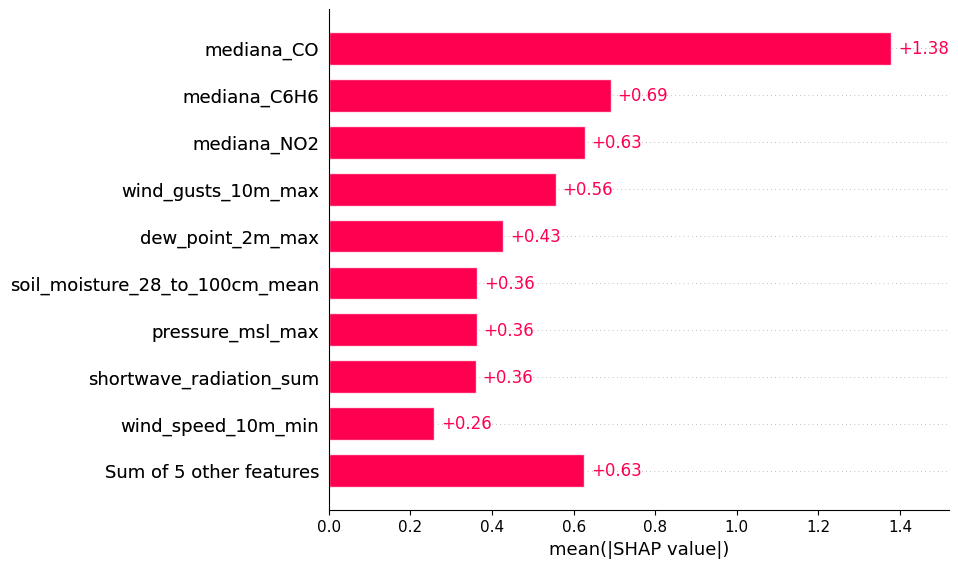

In [42]:
modello = cla_xgb.fit(
    df_finale_SF.loc[df_finale_SF['flag train'], list_var_traffic_new].values,
    df_finale_SF.loc[df_finale_SF['flag train'], 'target_pm10'].values
)


# feature matrix e target
X = df_finale_SF[list_var_traffic_new]
y = df_finale_SF["target_pm10"]

# background (campione del dataset)
background = X.sample(100, random_state=42)

# SHAP explainer
explainer = shap.Explainer(modello, background)

# calcolo valori SHAP
shap_values = explainer(X)

# plot importanza globale
shap.plots.bar(shap_values)

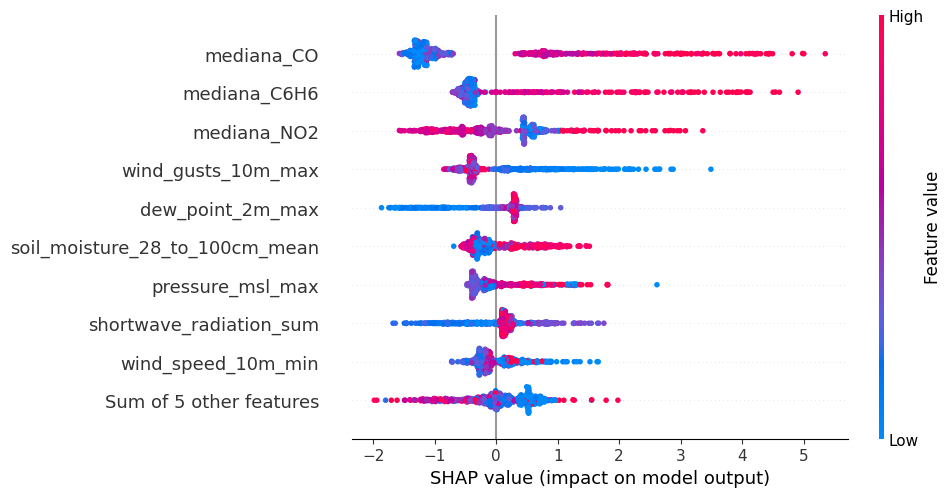

In [43]:
shap.plots.beeswarm(shap_values)

## MODELLI XGB E RF NON OTTIMIZZATI

### RF

In [44]:

cla_rf_sf = RandomForestClassifier(
    n_estimators=100,          # numero di alberi
    max_depth=5,               # puoi partire con 5–10
    random_state=42,
    class_weight='balanced',   # IMPORTANTISSIMO per il tuo dataset
)

cla_rf_sf.fit(
    df_finale_SF.loc[df_finale_SF['flag train'], list_var_traffic_new].values,
    df_finale_SF.loc[df_finale_SF['flag train'], 'target_pm10'].values
)

df_finale_SF['prediction (rf)'] = cla_rf_sf.predict(
    df_finale_SF.loc[:, list_var_traffic_new].values
)

### XGB

In [45]:

mask_train = df_finale_SF["flag train"]
mask_test = df_finale_SF["flag test"]

X_train = df_finale_SF.loc[mask_train, list_var_traffic_new]
y_train = df_finale_SF.loc[mask_train, "target_pm10"]

X_test = df_finale_SF.loc[mask_test, list_var_traffic_new]
y_test = df_finale_SF.loc[mask_test, "target_pm10"]

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos 

cla_xgb_sf = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.5,
    reg_alpha=0.1,
    reg_lambda=2.0,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

cla_xgb_sf.fit(X_train, y_train)

df_finale_SF["proba_xgb"] = cla_xgb_sf.predict_proba(
    df_finale_SF[list_var_traffic_new]
)[:, 1]

soglia_xgb = 0.34

df_finale_SF["prediction (xgb)"] = (
    df_finale_SF["proba_xgb"] >= soglia_xgb
).astype(int)

y_pred_test = df_finale_SF.loc[mask_test, "prediction (xgb)"]

results_xgb = pd.DataFrame([{
    "Model": "xgb",
    "soglia": soglia_xgb,
    "Accuracy": skl_metr.accuracy_score(y_test, y_pred_test),
    "Precision": skl_metr.precision_score(y_test, y_pred_test, zero_division=0),
    "Recall": skl_metr.recall_score(y_test, y_pred_test, zero_division=0),
    "F1-score": skl_metr.f1_score(y_test, y_pred_test, zero_division=0),
    "MCC": skl_metr.matthews_corrcoef(y_test, y_pred_test)
}]).round(4)



### CONFRONTO XGB E RF

#### CONFUSION MATRIX RF

In [46]:
#list_var_traffic_new e df_finale_SF
df_pivot = pd.pivot_table(df_finale_SF.loc[df_finale_SF['flag test'], :],
                          index='target_pm10', columns='prediction (rf)',
                          values='giorno', aggfunc='count', fill_value=0)
df_pivot.style.background_gradient(vmin=0, vmax=5).format(precision=0)

prediction (rf),0,1
target_pm10,,
0,190,11
1,8,3


#### CONFUSION MATRIX XGB

In [47]:
#list_var_traffic_new e df_finale_SF

df_pivot = pd.pivot_table(df_finale_SF.loc[df_finale_SF['flag test'], :],
                          index='target_pm10', columns='prediction (xgb)',
                          values='giorno', aggfunc='count', fill_value=0)
df_pivot.style.background_gradient(vmin=0, vmax=5).format(precision=0)

prediction (xgb),0,1
target_pm10,,
0,185,16
1,6,5


#### ACCURACY

In [48]:
#list_var_traffic_new e df_finale_SF

acc_rf_new = skl_metr.accuracy_score(df_finale_SF.loc[df_finale_SF['flag test'], 'target_pm10'],
                                   df_finale_SF.loc[df_finale_SF['flag test'], 'prediction (rf)'] )
acc_xgb_new = skl_metr.accuracy_score(df_finale_SF.loc[df_finale_SF['flag test'], 'target_pm10'],
                                   df_finale_SF.loc[df_finale_SF['flag test'], 'prediction (xgb)'] )

print(f"Model accuracy (decision rf): {acc_rf_new:.2}")
print(f"Model accuracy (decision xgb): {acc_xgb_new:.2}")

Model accuracy (decision rf): 0.91
Model accuracy (decision xgb): 0.9


#### PRECISION

In [49]:
#list_var_traffic_new e df_finale_SF
pre_rf_new = skl_metr.precision_score(df_finale_SF.loc[df_finale_SF['flag test'], 'target_pm10'] == 1,
                                    df_finale_SF.loc[df_finale_SF['flag test'], 'prediction (rf)'] == 1)
pre_xgb_new = skl_metr.precision_score(df_finale_SF.loc[df_finale_SF['flag test'], 'target_pm10'] == 1,
                                    df_finale_SF.loc[df_finale_SF['flag test'], 'prediction (xgb)'] == 1)

print(f'Model precision (decision rf): {pre_rf_new:.2}')
print(f'Model precision (decision xgb): {pre_xgb_new:.2}')

Model precision (decision rf): 0.21
Model precision (decision xgb): 0.24


#### RECALL

In [50]:
#list_var_traffic_new e df_finale_SF

rec_rf_new = skl_metr.recall_score(df_finale_SF.loc[df_finale_SF['flag test'], 'target_pm10'] == 1,
                                 df_finale_SF.loc[df_finale_SF['flag test'], 'prediction (rf)'] == 1)
rec_xgb_new = skl_metr.recall_score(df_finale_SF.loc[df_finale_SF['flag test'], 'target_pm10'] == 1,
                                 df_finale_SF.loc[df_finale_SF['flag test'], 'prediction (xgb)'] == 1)

print(f'Model recall (rf): {rec_rf_new:.2}')
print(f'Model recall (xgb): {rec_xgb_new:.2}')

Model recall (rf): 0.27
Model recall (xgb): 0.45


#### F-SCORE

In [51]:
#list_var_traffic_new e df_finale_SF

rec_rf_new = skl_metr.f1_score(df_finale_SF.loc[df_finale_SF['flag test'], 'target_pm10'] == 1,
                                 df_finale_SF.loc[df_finale_SF['flag test'], 'prediction (rf)'] == 1)
rec_xgb_new = skl_metr.f1_score(df_finale_SF.loc[df_finale_SF['flag test'], 'target_pm10'] == 1,
                                 df_finale_SF.loc[df_finale_SF['flag test'], 'prediction (xgb)'] == 1)

print(f'Model f-score (rf): {rec_rf_new:.2}')
print(f'Model f-score (xgb): {rec_xgb_new:.2}')

Model f-score (rf): 0.24
Model f-score (xgb): 0.31


#### M-SCORE

In [52]:
#list_var_traffic_new e df_finale_SF


rec_rf_new = skl_metr.matthews_corrcoef(df_finale_SF.loc[df_finale_SF['flag test'], 'target_pm10'] == 1,
                                 df_finale_SF.loc[df_finale_SF['flag test'], 'prediction (rf)'] == 1)
rec_xgb_new = skl_metr.matthews_corrcoef(df_finale_SF.loc[df_finale_SF['flag test'], 'target_pm10'] == 1,
                                 df_finale_SF.loc[df_finale_SF['flag test'], 'prediction (xgb)'] == 1)

print(f'Model m-score (rf): {rec_rf_new:.2}')
print(f'Model m-score (xgb): {rec_xgb_new:.2}')

Model m-score (rf): 0.19
Model m-score (xgb): 0.28


#### TABELLA

In [53]:

df_test_new = df_finale_SF.loc[df_finale_SF['flag test']]

y_true = df_test_new['target_pm10']

models = {
    "rf": "prediction (rf)",
    "xgb": "prediction (xgb)"
}

results = []

for name, col in models.items():
    y_pred = df_test_new[col]

    results.append({
        "Model": name,
        "Accuracy": skl_metr.accuracy_score(y_true, y_pred),
        "Precision": skl_metr.precision_score(y_true, y_pred),
        "Recall": skl_metr.recall_score(y_true, y_pred),
        "F1-score": skl_metr.f1_score(y_true, y_pred),
        "MCC": skl_metr.matthews_corrcoef(y_true, y_pred)
    })

df_results_sf = pd.DataFrame(results)

df_results_sf = df_results_sf.round(4)
df_results_sf

,Model,Accuracy,Precision,Recall,F1-score,MCC
0,rf,0.9104,0.2143,0.2727,0.2400,0.1947
1,xgb,0.8962,0.2381,0.4545,0.3125,0.2784


#### FEATURE IMPORTANCE XGB


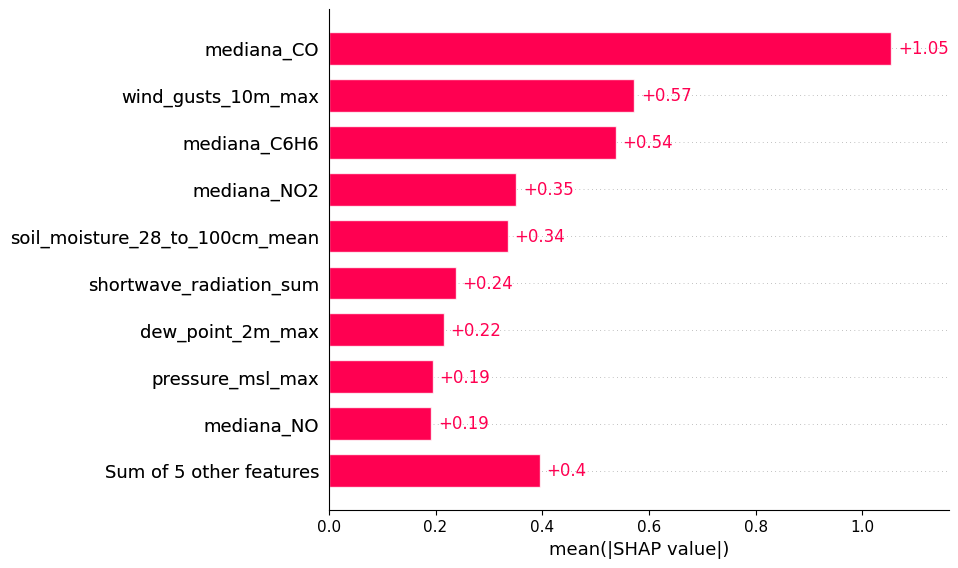

In [54]:
modello = cla_xgb_sf.fit(
    df_finale_SF.loc[df_finale_SF['flag train'], list_var_traffic_new].values,
    df_finale_SF.loc[df_finale_SF['flag train'], 'target_pm10'].values
)



# feature matrix e target
X = df_finale_SF[list_var_traffic_new]
y = df_finale_SF["target_pm10"]

# background (campione del dataset)
background = X.sample(100, random_state=42)

# SHAP explainer
explainer = shap.Explainer(modello, background)

# calcolo valori SHAP
shap_values = explainer(X)

# plot importanza globale
shap.plots.bar(shap_values)

# MODELLO URBANO (GM E VC)

## CREAZIONE DF AGENTI+METEO

In [55]:
df_merge_VC['target_pm10'] = df_merge_VC['PM10'] > 50
df_merge_VC["target_pm10"] = df_merge_VC["target_pm10"].map({True: 1, False: 0})

df_merge_VC.target_pm10.value_counts()

target_pm10
0    669
1     22
Name: count, dtype: int64

In [56]:
df_merge_GM['target_pm10'] = df_merge_GM['PM10'] > 50
df_merge_GM["target_pm10"] = df_merge_GM["target_pm10"].map({True: 1, False: 0})

df_merge_GM.target_pm10.value_counts()

target_pm10
0    666
1     25
Name: count, dtype: int64

In [57]:
df_merge_GM['giorno'] = pd.to_datetime(df_merge_GM['giorno'])
df_merge_VC['giorno'] = pd.to_datetime(df_merge_VC['giorno'])

In [58]:
df_merge_GM.columns

Index(['giorno', 'PM10', 'media_O3', 'mediana_O3', 'massimo_O3', 'PM2.5',
       'media_NO2', 'mediana_NO2', 'massimo_NO2', 'flag_PM25_missing',
       'flag_PM25_SF', 'flag_O3_missing', 'flag_O3_VC', 'flag_O3_interpol',
       'flag_NO2_missing', 'mese_giorno', 'anno', 'flag_NO2_2023',
       'target_pm10'],
      dtype='str')

In [59]:
to_drop = ['flag_PM25_missing',
       'flag_PM25_SF', 'flag_O3_missing', 'flag_O3_VC', 'flag_O3_interpol',
       'flag_NO2_missing', 'mese_giorno', 'anno', 'flag_NO2_2023','PM2.5','PM10']

for d in to_drop:
       df_merge_GM = df_merge_GM.drop(d,axis=1)

In [60]:
df_merge_VC.columns

Index(['giorno', 'PM10', 'media_O3', 'mediana_O3', 'massimo_O3', 'media_NO2',
       'mediana_NO2', 'massimo_NO2', 'flag_O3_missing', 'flag_O3_GM',
       'flag_NO2_missing', 'flag_NO2_VC', 'mese_giorno', 'anno',
       'flag_NO2_2023', 'target_pm10'],
      dtype='str')

In [61]:
to_drop = [ 'flag_O3_missing', 'flag_O3_GM',
       'flag_NO2_missing', 'flag_NO2_VC', 'mese_giorno', 'anno',
       'flag_NO2_2023', 
        'PM10']

for d in to_drop:
       df_merge_VC = df_merge_VC.drop(d, axis=1)

In [62]:
df_merge_GM_VC = pd.concat([df_merge_VC, df_merge_GM], axis=0)

In [63]:
df_finale_urban = df_merge_GM_VC.merge(daily_df, left_on='giorno', right_on='date', how='left')

## SCELTA VARIABILI

In [64]:
list_var = ['precipitation_sum',
                    'cloud_cover_max',
                    'wind_speed_10m_min',
                    'wind_gusts_10m_max',
                    'pressure_msl_max',
                    'soil_moisture_28_to_100cm_mean',
                    'dew_point_2m_max',
                    'temperature_2m_max',
                    'shortwave_radiation_sum'
                     ]

In [65]:
list_urban= ['media_O3', 'mediana_O3', 'massimo_O3', 'media_NO2',
       'mediana_NO2', 'massimo_NO2',]



In [66]:
# creo una lista di variabili da usare nel modello

list_var_urban = list_var + list_urban

In [67]:
list_var_urban

['precipitation_sum',
 'cloud_cover_max',
 'wind_speed_10m_min',
 'wind_gusts_10m_max',
 'pressure_msl_max',
 'soil_moisture_28_to_100cm_mean',
 'dew_point_2m_max',
 'temperature_2m_max',
 'shortwave_radiation_sum',
 'media_O3',
 'mediana_O3',
 'massimo_O3',
 'media_NO2',
 'mediana_NO2',
 'massimo_NO2']

### CORRELAZIONE


In [68]:
corr_matrix = df_finale_urban[list_var_urban].corr(numeric_only=True)

list_corr = []
cols = corr_matrix.columns.tolist()

for ii, i in enumerate(cols[:-1]):
    for jj, j in enumerate(cols[ii+1:]):
        list_corr.append([i, j, corr_matrix.loc[i, j]])

df_corr = pd.DataFrame(list_corr, columns=['varA', 'varB', 'correlation'])
df_corr = df_corr.sort_values('correlation', ascending=False, key=abs)

df_corr.loc[df_corr['correlation'] > 0.7,:]
#df_corr.loc[df_corr['correlation'] > 0.98,:]

,varA,varB,correlation
102,media_NO2,mediana_NO2,0.982958
90,media_O3,mediana_O3,0.981468
91,media_O3,massimo_O3,0.944200
69,dew_point_2m_max,temperature_2m_max,0.905697
95,mediana_O3,massimo_O3,0.891818
103,media_NO2,massimo_NO2,0.865362
84,shortwave_radiation_sum,media_O3,0.857534
78,temperature_2m_max,media_O3,0.856493
86,shortwave_radiation_sum,massimo_O3,0.855191
80,temperature_2m_max,massimo_O3,0.855028


### VSCORE

In [69]:
df_vscore = df_finale_urban.copy()

for k in list_var_urban :   # per ciascuna delle colonne numeriche ...

    df_vscore[k] = pd.qcut(df_vscore[k], q=min(20, df_vscore[k].nunique()+1), duplicates='drop')                     # ... binning ...
    df_vscore[k] = df_vscore[k].map({k:'bin'+f'{kk}'.zfill(2) for kk,k in enumerate(sorted(df_vscore[k].unique()))}) # ... resetting labels

In [70]:
list_vscores = []

list_vars_vscore = list_var_urban
list_vars_vscore = list(df_vscore[list_vars_vscore].nunique().sort_values(ascending=False).index)

for ii, i in enumerate(list_vars_vscore[:-1]) :
    for jj, j in enumerate(list_vars_vscore[ii+1:]) :

        df_contingency = df_vscore.groupby([i,j]).agg({'giorno':'count'})
        df_contingency = df_contingency.unstack().replace(0, np.nan)
        df_contingency = df_contingency.dropna(axis=0, how='all').dropna(axis=1, how='all')
        df_contingency = df_contingency.fillna(0).astype(int)

        r, c = df_contingency.shape
        n = df_contingency.sum().sum()

        vscore = scp_cont.association(df_contingency.values, method="tschuprow")
        vscore = max(0, vscore**2 * np.sqrt((c-1) * (r-1)) * (n-1) - (r-1) * (c-1))
        vscore = vscore / min( (r-1) * (n-c), (c-1) * (n-r) )
        vscore = np.sqrt(vscore)

        list_vscores.append([i,j,vscore])

df_vscore = pd.DataFrame(list_vscores, columns=['varA', 'varB', 'v-score'])
df_vscore = df_vscore.sort_values('v-score', ascending=False)

In [71]:
df_vscore.head(20).style.background_gradient(vmin=0, vmax=1).format(precision=2)

,varA,varB,v-score
87,media_NO2,mediana_NO2,0.56
90,media_O3,mediana_O3,0.50
78,massimo_O3,media_O3,0.39
51,dew_point_2m_max,temperature_2m_max,0.33
86,media_NO2,massimo_NO2,0.32
79,massimo_O3,mediana_O3,0.31
71,temperature_2m_max,media_O3,0.29
41,soil_moisture_28_to_100cm_mean,temperature_2m_max,0.28
99,massimo_NO2,mediana_NO2,0.28
69,temperature_2m_max,massimo_O3,0.28


### CORRELAZIONE DI PEARSON CONFRONTO PM10

In [72]:
df_corr_p = (
    df_finale_urban[list_var_urban]
    .corrwith(df_finale_urban["target_pm10"])
    .abs()
    .sort_values(ascending=False)
    .reset_index()
)

df_corr_p.columns = ["varA", "correlation"]
df_corr_p["varB"] = "target_pm10"

df_corr_p

,varA,correlation,varB
0,mediana_NO2,0.206413,target_pm10
1,media_NO2,0.204698,target_pm10
2,massimo_O3,0.178065,target_pm10
3,media_O3,0.176396,target_pm10
4,mediana_O3,0.173970,target_pm10
5,shortwave_radiation_sum,0.155943,target_pm10
6,temperature_2m_max,0.152413,target_pm10
7,wind_gusts_10m_max,0.129712,target_pm10
8,massimo_NO2,0.126073,target_pm10
9,dew_point_2m_max,0.116795,target_pm10


### CORRELAZIONE DI SPEARMAN CONFRONTO PM10

In [73]:
df_corr_s = (
    df_finale_urban[list_var_urban]
    .corrwith(df_finale_urban["target_pm10"], method='spearman')
    .abs()
    .sort_values(ascending=False)
    .reset_index()
)

df_corr_s.columns = ["varA", "correlation"]
df_corr_s["varB"] = "target_pm10"

df_corr_s

,varA,correlation,varB
0,media_O3,0.194251,target_pm10
1,mediana_O3,0.192360,target_pm10
2,mediana_NO2,0.180901,target_pm10
3,massimo_O3,0.179863,target_pm10
4,media_NO2,0.179276,target_pm10
5,temperature_2m_max,0.155221,target_pm10
6,shortwave_radiation_sum,0.151858,target_pm10
7,wind_gusts_10m_max,0.147920,target_pm10
8,massimo_NO2,0.132046,target_pm10
9,dew_point_2m_max,0.125786,target_pm10


### VSCORE CONFRONTO PM10

In [74]:
df_vscore = df_finale_urban.copy()

for k in list_var_urban:   # per ciascuna delle colonne numeriche ...

    df_vscore[k] = pd.qcut(df_vscore[k], q=min(20, df_vscore[k].nunique()+1), duplicates='drop')                                # ... binning ...
    df_vscore[k] = df_vscore[k].map({k:'bin'+f'{kk}'.zfill(2) for kk,k in enumerate(sorted(df_vscore[k].dropna().unique()))})   # ... resetting labels

In [75]:
list_vscores = []

list_vars_vscore = list_var_urban
list_vars_vscore = list(df_vscore[list_vars_vscore].nunique().sort_values(ascending=False).index)

for ii, i in enumerate(list_vars_vscore) :

    df_contingency = df_vscore.groupby([i,'target_pm10']).agg({'giorno':'count'})
    df_contingency = df_contingency.unstack().replace(0, np.nan)
    df_contingency = df_contingency.dropna(axis=0, how='all').dropna(axis=1, how='all')
    df_contingency = df_contingency.fillna(0).astype(int)

    r, c = df_contingency.shape
    n = df_contingency.sum().sum()

    vscore = scp_cont.association(df_contingency.values, method="tschuprow")
    vscore = max(0, vscore**2 * np.sqrt((c-1) * (r-1)) * (n-1) - (r-1) * (c-1))
    vscore = vscore / min( (r-1) * (n-c), (c-1) * (n-r) )
    vscore = np.sqrt(vscore)

    list_vscores.append([i,'target_pm10',vscore])

df_couples = pd.DataFrame(list_vscores, columns=['var-x', 'var-y', 'v-score'])
df_couples = df_couples.sort_values('v-score', ascending=False)

In [76]:
df_couples.head(12).style.background_gradient(vmin=0, vmax=.3).format(precision=2)

,var-x,var-y,v-score
9,media_O3,target_pm10,0.26
3,soil_moisture_28_to_100cm_mean,target_pm10,0.25
7,massimo_O3,target_pm10,0.24
5,shortwave_radiation_sum,target_pm10,0.23
10,mediana_O3,target_pm10,0.22
2,wind_gusts_10m_max,target_pm10,0.21
12,mediana_NO2,target_pm10,0.20
8,media_NO2,target_pm10,0.20
1,pressure_msl_max,target_pm10,0.19
6,temperature_2m_max,target_pm10,0.17


### INFORMATION VALUE CONFRONTO PM10

In [77]:

features = list_var_urban
target = 'target_pm10'  # 1 = sopra soglia, 0 = sotto

# prendi solo le colonne che ti servono
df_sub = df_finale_urban[features + [target]]

# calcolo IV solo su queste
iv_df = sc.iv(df_sub, y=target)

In [78]:
iv_df.head(20).style.background_gradient(vmin=0, vmax=.5).format(precision=2)

,variable,info_value
2,precipitation_sum,1.35
12,massimo_NO2,1.06
7,mediana_NO2,1.04
11,wind_gusts_10m_max,0.80
9,cloud_cover_max,0.72
8,wind_speed_10m_min,0.68
10,pressure_msl_max,0.56
0,massimo_O3,0.53
13,soil_moisture_28_to_100cm_mean,0.47
1,media_NO2,0.38


In [79]:
# split direttamente sul dataframe
xtr, xte, ytr, yte = skl_msel.train_test_split(
    df_finale_urban,
    df_finale_urban['target_pm10'],
    test_size=0.25,
    random_state=33
)

# flag basati sull'index
df_finale_urban['flag train'] = df_finale_urban.index.isin(xtr.index)
df_finale_urban['flag test'] = df_finale_urban.index.isin(xte.index)

In [80]:
train_iv = xtr.copy()
train_iv[target] = ytr.values

test_iv = xte.copy()
test_iv[target] = yte.values

iv_train = sc.iv(train_iv[features + [target]], y=target)
iv_test = sc.iv(test_iv[features + [target]], y=target)

iv_compare = iv_train.merge(
    iv_test,
    on="variable",
    how="outer",
    suffixes=("_train", "_test")
)

iv_compare = iv_compare.sort_values("info_value_train", ascending=False)

iv_compare

,variable,info_value_train,info_value_test
8,precipitation_sum,1.475924,1.800228
2,massimo_NO2,1.008215,0.693246
6,mediana_NO2,0.950221,0.661737
0,cloud_cover_max,0.928950,1.592443
14,wind_speed_10m_min,0.714398,0.535162
13,wind_gusts_10m_max,0.687008,0.566034
9,pressure_msl_max,0.534660,0.314469
3,massimo_O3,0.507569,0.323004
11,soil_moisture_28_to_100cm_mean,0.468022,0.291568
7,mediana_O3,0.383756,0.262032


Come per il df_finale_SF tengo le due mediane

In [81]:
list_var_urban_new = ['precipitation_sum',
                    'cloud_cover_max',
                    'wind_speed_10m_min',
                    'wind_gusts_10m_max',
                    'pressure_msl_max',
                    'soil_moisture_28_to_100cm_mean',
                    'dew_point_2m_max',
                    'temperature_2m_max',
                    'shortwave_radiation_sum',                     
                    'mediana_O3',
                    'mediana_NO2']

## MODELLO OTTIMIZZATO SUL DF COMPLETO

Anche qua provo ad utilizzare il modello ottimizzato usando il df con i dati raccolti da tutte le centraline

In [82]:
# calcolo peso per class imbalance
n_neg = (df_finale_urban['target_pm10'] == 0).sum()
n_pos = (df_finale_urban['target_pm10'] == 1).sum()
scale_pos_weight = n_neg / n_pos

cla_xgb = XGBClassifier(
    **params,
    scale_pos_weight=scale_pos_weight
)

cla_xgb.fit(
    df_finale_urban.loc[df_finale_urban['flag train'], list_var_urban_new].values,
    df_finale_urban.loc[df_finale_urban['flag train'], 'target_pm10'].values
)

# probabilità della classe 1
df_finale_urban['proba (xgb)'] = cla_xgb.predict_proba(
    df_finale_urban.loc[:, list_var_urban_new].values
)[:, 1]

df_finale_urban['prediction (xgb)'] = (df_finale_urban['proba (xgb)'] > 0.3).astype(int)

### PRECISION

In [83]:
pre_xgb = skl_metr.precision_score(df_finale_urban.loc[df_finale_urban['flag test'], 'target_pm10'] == 1,
                                    df_finale_urban.loc[df_finale_urban['flag test'], 'prediction (xgb)'] == 1)

print(f'Model precision (decision xgb): {pre_xgb:.2}')

Model precision (decision xgb): 0.42


### RECALL

In [84]:
rec_xgb = skl_metr.recall_score(df_finale_urban.loc[df_finale_urban['flag test'], 'target_pm10'] == 1,
                                 df_finale_urban.loc[df_finale_urban['flag test'], 'prediction (xgb)'] == 1)

print(f'Model recall (xgb): {rec_xgb:.2}')

Model recall (xgb): 0.73


### TABLE

In [85]:
df_pivot = pd.pivot_table(df_finale_urban.loc[df_finale_urban['flag test'], :],
                          index='target_pm10', columns='prediction (xgb)',
                          values='giorno', aggfunc='count', fill_value=0)
df_pivot.style.background_gradient(vmin=0, vmax=5).format(precision=0)

prediction (xgb),0,1
target_pm10,,
0,324,11
1,3,8


In [86]:
df_test = df_finale_urban.loc[df_finale_urban['flag test']]

y_true = df_test['target_pm10']

models = {
    "xgb": "prediction (xgb)"
}

results = []

for name, col in models.items():
    y_pred = df_test[col]

    results.append({
        "Model": name,
        "Accuracy": skl_metr.accuracy_score(y_true, y_pred),
        "Precision": skl_metr.precision_score(y_true, y_pred),
        "Recall": skl_metr.recall_score(y_true, y_pred),
        "F1-score": skl_metr.f1_score(y_true, y_pred),
        "MCC": skl_metr.matthews_corrcoef(y_true, y_pred)
    })

df_results = pd.DataFrame(results)

df_results = df_results.round(4)
df_results

,Model,Accuracy,Precision,Recall,F1-score,MCC
0,xgb,0.9595,0.4211,0.7273,0.5333,0.5348


Qua il modello ottimizzato sul df completo si comporta abbastanza bene; guardiamo ora come si comportano RF e XGB non ottimizzati

## MODELLI RF E XGB NON OTTIMIZZATI

### RF

In [87]:


cla_rf_ur = RandomForestClassifier(
    n_estimators=100,          # numero di alberi
    max_depth=5,               # puoi partire con 5–10
    random_state=42,
    class_weight='balanced',   # IMPORTANTISSIMO per il tuo dataset
)

cla_rf_ur.fit(
    df_finale_urban.loc[df_finale_urban['flag train'], list_var_urban_new].values,
    df_finale_urban.loc[df_finale_urban['flag train'], 'target_pm10'].values
)

df_finale_urban['prediction (rf)'] = cla_rf_ur.predict(
    df_finale_urban.loc[:, list_var_urban_new].values
)

### XGB

In [88]:

# calcolo peso per class imbalance
n_neg = (df_finale_urban['target_pm10'] == 0).sum()
n_pos = (df_finale_urban['target_pm10'] == 1).sum()
scale_pos_weight = n_neg / n_pos

cla_xgb_ur = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,  
#    eval_metric='logloss',
    random_state=42
)

cla_xgb_ur.fit(
    df_finale_urban.loc[df_finale_urban['flag train'], list_var_urban_new].values,
    df_finale_urban.loc[df_finale_urban['flag train'], 'target_pm10'].values
)

df_finale_urban['prediction (xgb)'] = cla_xgb_ur.predict(
    df_finale_urban.loc[:, list_var_urban_new].values
)

df_finale_urban['proba_xgb'] = cla_xgb_ur.predict_proba(
    df_finale_urban.loc[:, list_var_urban_new].values
)[:, 1]

### CONFRONTO XGB E RF

#### CONFUSION MATRIX RF

In [89]:
df_pivot = pd.pivot_table(df_finale_urban.loc[df_finale_urban['flag test'], :],
                          index='target_pm10', columns='prediction (rf)',
                          values='giorno', aggfunc='count', fill_value=0)
df_pivot.style.background_gradient(vmin=0, vmax=5).format(precision=0)

prediction (rf),0,1
target_pm10,,
0,311,24
1,2,9


#### CONFUSION MATRIX XGB

In [90]:
df_pivot = pd.pivot_table(df_finale_urban.loc[df_finale_urban['flag test'], :],
                          index='target_pm10', columns='prediction (xgb)',
                          values='giorno', aggfunc='count', fill_value=0)
df_pivot.style.background_gradient(vmin=0, vmax=5).format(precision=0)

prediction (xgb),0,1
target_pm10,,
0,323,12
1,3,8


#### ACCURACY

In [91]:
acc_rf_new = skl_metr.accuracy_score(df_finale_urban.loc[df_finale_urban['flag test'], 'target_pm10'],
                                   df_finale_urban.loc[df_finale_urban['flag test'], 'prediction (rf)'] )
acc_xgb_new = skl_metr.accuracy_score(df_finale_urban.loc[df_finale_urban['flag test'], 'target_pm10'],
                                   df_finale_urban.loc[df_finale_urban['flag test'], 'prediction (xgb)'] )

print(f"Model accuracy (decision rf): {acc_rf_new:.2}")
print(f"Model accuracy (decision xgb): {acc_xgb_new:.2}")

Model accuracy (decision rf): 0.92
Model accuracy (decision xgb): 0.96


#### PRECISION

In [92]:
pre_rf_new = skl_metr.precision_score(df_finale_urban.loc[df_finale_urban['flag test'], 'target_pm10'] == 1,
                                    df_finale_urban.loc[df_finale_urban['flag test'], 'prediction (rf)'] == 1)
pre_xgb_new = skl_metr.precision_score(df_finale_urban.loc[df_finale_urban['flag test'], 'target_pm10'] == 1,
                                    df_finale_urban.loc[df_finale_urban['flag test'], 'prediction (xgb)'] == 1)

print(f'Model precision (decision rf): {pre_rf_new:.2}')
print(f'Model precision (decision xgb): {pre_xgb_new:.2}')

Model precision (decision rf): 0.27
Model precision (decision xgb): 0.4


#### RECALL

In [93]:
rec_rf_new = skl_metr.recall_score(df_finale_urban.loc[df_finale_urban['flag test'], 'target_pm10'] == 1,
                                 df_finale_urban.loc[df_finale_urban['flag test'], 'prediction (rf)'] == 1)
rec_xgb_new = skl_metr.recall_score(df_finale_urban.loc[df_finale_urban['flag test'], 'target_pm10'] == 1,
                                 df_finale_urban.loc[df_finale_urban['flag test'], 'prediction (xgb)'] == 1)

print(f'Model recall (rf): {rec_rf_new:.2}')
print(f'Model recall (xgb): {rec_xgb_new:.2}')

Model recall (rf): 0.82
Model recall (xgb): 0.73


#### F-SCORE

In [94]:
rec_rf_new = skl_metr.f1_score(df_finale_urban.loc[df_finale_urban['flag test'], 'target_pm10'] == 1,
                                 df_finale_urban.loc[df_finale_urban['flag test'], 'prediction (rf)'] == 1)
rec_xgb_new = skl_metr.f1_score(df_finale_urban.loc[df_finale_urban['flag test'], 'target_pm10'] == 1,
                                 df_finale_urban.loc[df_finale_urban['flag test'], 'prediction (xgb)'] == 1)

print(f'Model f-score (rf): {rec_rf_new:.2}')
print(f'Model f-score (xgb): {rec_xgb_new:.2}')

Model f-score (rf): 0.41
Model f-score (xgb): 0.52


#### M-SCORE

In [95]:
rec_rf_new = skl_metr.matthews_corrcoef(df_finale_urban.loc[df_finale_urban['flag test'], 'target_pm10'] == 1,
                                 df_finale_urban.loc[df_finale_urban['flag test'], 'prediction (rf)'] == 1)
rec_xgb_new = skl_metr.matthews_corrcoef(df_finale_urban.loc[df_finale_urban['flag test'], 'target_pm10'] == 1,
                                 df_finale_urban.loc[df_finale_urban['flag test'], 'prediction (xgb)'] == 1)

print(f'Model m-score (rf): {rec_rf_new:.2}')
print(f'Model m-score (xgb): {rec_xgb_new:.2}')

Model m-score (rf): 0.45
Model m-score (xgb): 0.52


#### TABELLA

In [96]:


df_test_new = df_finale_urban.loc[df_finale_urban['flag test']]

y_true = df_test_new['target_pm10']

models = {
    "rf": "prediction (rf)",
    "xgb": "prediction (xgb)"
}

results = []

for name, col in models.items():
    y_pred = df_test_new[col]

    results.append({
        "Model": name,
        "Accuracy": skl_metr.accuracy_score(y_true, y_pred),
        "Precision": skl_metr.precision_score(y_true, y_pred),
        "Recall": skl_metr.recall_score(y_true, y_pred),
        "F1-score": skl_metr.f1_score(y_true, y_pred),
        "MCC": skl_metr.matthews_corrcoef(y_true, y_pred)
    })

df_results_urban_new = pd.DataFrame(results)

df_results_urban_new = df_results_urban_new.round(4)
df_results_urban_new

,Model,Accuracy,Precision,Recall,F1-score,MCC
0,rf,0.9249,0.2727,0.8182,0.4091,0.4459
1,xgb,0.9566,0.4000,0.7273,0.5161,0.5198


#### FEATURE IMPORTANCE XGB

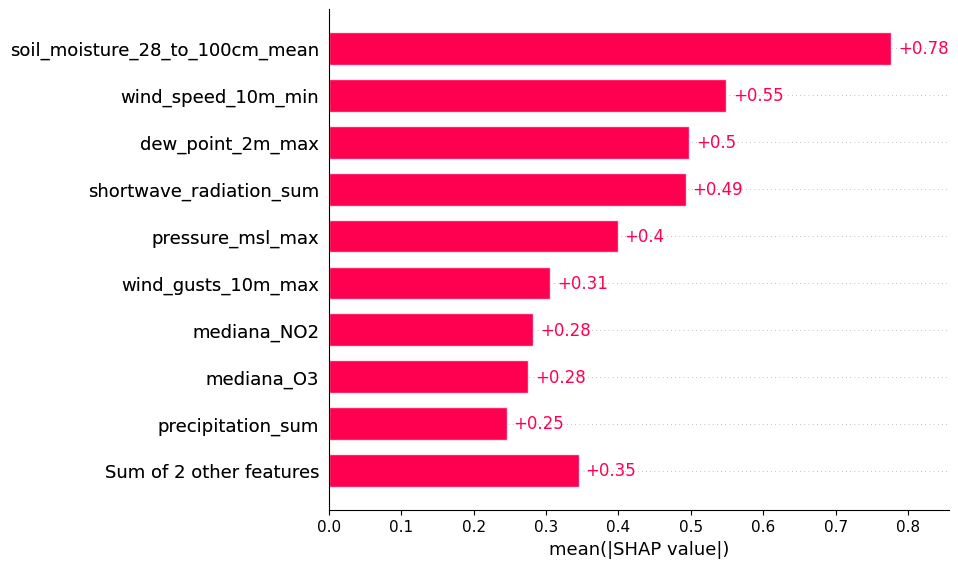

In [97]:
modello = cla_xgb_ur.fit(
    df_finale_urban.loc[df_finale_urban['flag train'], list_var_urban_new].values,
    df_finale_urban.loc[df_finale_urban['flag train'], 'target_pm10'].values
)

import shap

# feature matrix e target
X = df_finale_urban[list_var_urban_new]
y = df_finale_urban["target_pm10"]

# background (campione del dataset)
background = X.sample(100, random_state=42)

# SHAP explainer
explainer = shap.Explainer(modello, background)

# calcolo valori SHAP
shap_values = explainer(X)

# plot importanza globale
shap.plots.bar(shap_values)